# Data Quality, Cleaning & Enrichment Pipeline
**Project:** Sri Lanka Tourism Analytics (2018–2025)  
**Objective:** Clean, standardize, resolve duplicate entities, enrich geospatial/temporal dimensions, and enforce strict data quality contracts on consolidated tourism arrivals.

### 1. Environment & Library Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import country_converter as coco

# Plot styling for professional presentation
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

### 2. Consolidated Data Ingestion & Initial Profiling

In [2]:
DATA_PATH = Path("../data/processed/tourism_arrivals_combine.csv")
OUTPUT_PATH = Path("../data/processed/tourism_arrivals_clean.csv")

df_raw = pd.read_csv(DATA_PATH)
print("Initial Dimensions:", df_raw.shape)
print("Initial Unique Country Labels:", df_raw["Country"].nunique())
print("Total Raw Tourist Arrivals:", f"{df_raw['Tourist_Arrivals'].sum():,.0f}")
df_raw.head()

Initial Dimensions: (18900, 6)
Initial Unique Country Labels: 573
Total Raw Tourist Arrivals: 11,572,964


,Year,Country,Month,Tourist_Arrivals,Month_Number,Date
0,2018,"AFGHANISTAN, ISLAMIC REPUBLIC OF",January,83.0,1,2018-01-01
1,2018,"ALBANIA, REPUBLIC OF",January,14.0,1,2018-01-01
2,2018,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",January,38.0,1,2018-01-01
3,2018,"ANDORRA, PRINCIPALITY OF",January,4.0,1,2018-01-01
4,2018,"ANGOLA, REPUBLIC OF",January,0.0,1,2018-01-01


In [3]:
# Schema and Data Types Inspection
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 18900 entries, 0 to 18899
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              18900 non-null  int64  
 1   Country           18900 non-null  str    
 2   Month             18900 non-null  str    
 3   Tourist_Arrivals  18900 non-null  float64
 4   Month_Number      18900 non-null  int64  
 5   Date              18900 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 886.1 KB


### 3. Missing Values & Duplicate Inspection

In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing %": (df_raw.isnull().sum() / len(df_raw)) * 100
})
print("Missing Value Profile:")
print(missing_summary)

full_dups = df_raw.duplicated().sum()
key_dups = df_raw.duplicated(subset=["Year", "Country", "Month"]).sum()
print(f"\nFull row duplicates: {full_dups}")
print(f"Key duplicates (Year, Country, Month): {key_dups}")

Missing Value Profile:
                  Missing Count  Missing %
Year                          0        0.0
Country                       0        0.0
Month                         0        0.0
Tourist_Arrivals              0        0.0
Month_Number                  0        0.0
Date                          0        0.0

Full row duplicates: 176
Key duplicates (Year, Country, Month): 180


### 4. Value Range & Anomaly Validation

In [5]:
neg_count = (df_raw["Tourist_Arrivals"] < 0).sum()
zero_count = (df_raw["Tourist_Arrivals"] == 0).sum()
zero_pct = (zero_count / len(df_raw)) * 100

print(f"Negative values detected: {neg_count}")
print(f"Zero arrivals records: {zero_count:,} ({zero_pct:.2f}% of raw rows)")

Negative values detected: 0
Zero arrivals records: 5,814 (30.76% of raw rows)


### 5. Identification of Dirty Data & Entity Fragmentation
Raw annual SLTDA government reports contain:
1. **Alphabet index dividers** (e.g. `'A'`, `'B'`, ..., `'Z'`) from report formatting.
2. **Regional headers and table summary labels** (e.g. `'EUROPEAN UNION'`, `'TOTAL'`, `'Country'`).
3. **Casing and naming variants** across years (e.g. `'India'`, `'INDIA'`, `'INDIA, REPUBLIC OF'`).

In [6]:
# Single-letter section divider detection
single_chars = sorted(df_raw[df_raw["Country"].str.strip().str.len() <= 1]["Country"].unique().tolist())
print(f"Alphabet section dividers detected ({len(single_chars)}):", single_chars)

# Casing inconsistency detection
case_groups = df_raw.groupby(df_raw["Country"].str.strip().str.lower())["Country"].nunique()
fragmented_entities = case_groups[case_groups > 1]
print(f"Number of country entities fragmented across multiple naming/casing variations: {len(fragmented_entities)}")
print("Sample fragmented entities:", list(fragmented_entities.head(10).index))

Alphabet section dividers detected (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z']
Number of country entities fragmented across multiple naming/casing variations: 200
Sample fragmented entities: ['afghanistan', 'albania', 'algeria', 'andorra', 'angola', 'antigua & barbuda', 'antigua and barbuda', 'argentina', 'armenia', 'australia']


### 6. Entity Resolution & Standardization Pipeline
1. **Filter Non-Country Artifacts:** Drop single-letter dividers and report layout labels.
2. **Spelling & Territory Resolution:** Apply curated mappings for historical or regional territories.
3. **ISO Standardization:** Map entities to standard short names via `country_converter`.
4. **Encoding Normalization:** Ensure clean standard ASCII names.

In [7]:
# 1. Filter layout artifacts
non_country_labels = {
    "country", "total", "european union", "republic", "equatorial", "central african"
}
valid_mask = (
    (df_raw["Country"].str.strip().str.len() > 1) &
    (~df_raw["Country"].str.strip().str.lower().isin(non_country_labels))
)
df_clean = df_raw[valid_mask].copy()

# 2. Curated territory and spelling overrides
custom_country_map = {
    "Cote d'lvoire": "Cote d'Ivoire",
    "KOSOVAR": "Kosovo",
    "Kosovar": "Kosovo",
    "NETHERLAND ANTILLES": "Netherlands Antilles",
    "Netherlands Antilles": "Netherlands Antilles",
    "SOLOMAN ISLANDS": "Solomon Islands",
}
df_clean["Country"] = df_clean["Country"].replace(custom_country_map)

# 3. ISO Country Standardization
cc = coco.CountryConverter()
standardized = cc.pandas_convert(
    series=df_clean["Country"],
    to="name_short",
    not_found=None
)
df_clean["Country"] = standardized.fillna(df_clean["Country"].str.title())

# 4. Standardize ASCII representations
ascii_map = {
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Türkiye": "Turkey"
}
df_clean["Country"] = df_clean["Country"].replace(ascii_map)

# Numeric sanitization
df_clean["Tourist_Arrivals"] = pd.to_numeric(df_clean["Tourist_Arrivals"], errors="coerce").fillna(0)
df_clean = df_clean[df_clean["Tourist_Arrivals"] >= 0]

Netherlands Antilles not found in regex


### 7. Feature & Dimension Enrichment
Enrich dataset with:
- **`ISO3`**: 3-letter international standard country code (enables choropleth / geospatial analytics).
- **`Continent`**: Regional grouping for macro-level analysis.
- **`Quarter`**: Quarterly grouping (`Q1`–`Q4`).
- **`Season`**: Sri Lanka tourism seasonality (`Peak` vs `Off-Peak`).
- **`Period`**: Macroeconomic shock phase (`Pre-Crisis`, `Crisis`, `Post-Crisis`).

In [8]:
# Geospatial Dimensions
df_clean["ISO3"] = cc.pandas_convert(series=df_clean["Country"], to="ISO3", not_found=None)
df_clean["Continent"] = cc.pandas_convert(series=df_clean["Country"], to="continent", not_found=None)

# Territory fallback overrides for complete geospatial mapping
df_clean.loc[df_clean["Country"] == "Netherlands Antilles", "ISO3"] = "ANT"
df_clean.loc[df_clean["Country"] == "Netherlands Antilles", "Continent"] = "America"
df_clean.loc[df_clean["Country"] == "Kosovo", "ISO3"] = "XKX"
df_clean.loc[df_clean["Country"] == "Kosovo", "Continent"] = "Europe"

# Temporal & Macroeconomic Dimensions
df_clean["Quarter"] = "Q" + ((df_clean["Month_Number"] - 1) // 3 + 1).astype(str)

# Seasonality: High season (Nov-Apr, Jul-Aug) vs Low/Monsoon season (May-Jun, Sep-Oct)
df_clean["Season"] = df_clean["Month_Number"].apply(
    lambda m: "Peak" if m in [1, 2, 3, 4, 7, 8, 11, 12] else "Off-Peak"
)

# Macroeconomic Crisis Period
df_clean["Period"] = np.select(
    [
        df_clean["Year"] <= 2019,
        df_clean["Year"].isin([2020, 2021]),
        df_clean["Year"] >= 2022
    ],
    [
        "Pre-Crisis (2018-2019)",
        "Crisis (2020-2021)",
        "Post-Crisis (2022-2025)"
    ],
    default="Other"
)

Netherlands Antilles not found in regex
Netherlands Antilles not found in regex


### 8. Re-aggregation & Deduplication
Aggregate tourist arrivals across unified country entities per `(Year, Country, ISO3, Continent, Month, Month_Number, Date, Quarter, Season, Period)` to ensure a perfectly unique panel dataset.

In [9]:
dimension_cols = [
    "Year", "Country", "ISO3", "Continent",
    "Month", "Month_Number", "Date",
    "Quarter", "Season", "Period"
]

df_cleaned = (
    df_clean.groupby(dimension_cols, as_index=False)["Tourist_Arrivals"]
    .sum()
)

# Chronological and alphabetical sorting
df_cleaned = df_cleaned.sort_values(["Date", "Country"]).reset_index(drop=True)
print("Final Cleaned Shape:", df_cleaned.shape)
print("Final Cleaned Unique Countries:", df_cleaned["Country"].nunique())
df_cleaned.head()

Final Cleaned Shape: (18288, 11)
Final Cleaned Unique Countries: 203


,Year,Country,ISO3,Continent,Month,Month_Number,Date,Quarter,Season,Period,Tourist_Arrivals
0,2018,Afghanistan,AFG,Asia,January,1,2018-01-01,Q1,Peak,Pre-Crisis (2018-2019),83.0
1,2018,Albania,ALB,Europe,January,1,2018-01-01,Q1,Peak,Pre-Crisis (2018-2019),14.0
2,2018,Algeria,DZA,Africa,January,1,2018-01-01,Q1,Peak,Pre-Crisis (2018-2019),38.0
3,2018,Andorra,AND,Europe,January,1,2018-01-01,Q1,Peak,Pre-Crisis (2018-2019),4.0
4,2018,Angola,AGO,Africa,January,1,2018-01-01,Q1,Peak,Pre-Crisis (2018-2019),0.0


### 9. Automated Data Quality Assertions (Data Contract)
Enforce production-grade validation tests to guarantee downstream modeling reliability.

In [10]:
# 1. Null check
assert df_cleaned["Tourist_Arrivals"].isna().sum() == 0, "FAIL: Null arrivals found"

# 2. Negative value check
assert (df_cleaned["Tourist_Arrivals"] < 0).sum() == 0, "FAIL: Negative arrivals found"

# 3. Unique panel key check (Date x Country)
assert df_cleaned.duplicated(subset=["Date", "Country"]).sum() == 0, "FAIL: Duplicate panel keys"

# 4. Standard ISO3 length check
assert df_cleaned["ISO3"].str.len().eq(3).all(), "FAIL: Invalid ISO3 length detected"

# 5. Recognized continent check
valid_continents = {"Asia", "Europe", "America", "Oceania", "Africa", "Antarctica"}
assert set(df_cleaned["Continent"].unique()).issubset(valid_continents), "FAIL: Invalid continent detected"

# 6. Volume preservation check (>= 99.99%)
volume_preserved = (df_cleaned["Tourist_Arrivals"].sum() / df_raw["Tourist_Arrivals"].sum()) * 100
assert volume_preserved >= 99.99, f"FAIL: Excessive data loss ({volume_preserved:.4f}%)"

print("PASSED: All 6 automated data quality assertions completed successfully!")
print(f"Data Preservation Rate: {volume_preserved:.4f}%")

PASSED: All 6 automated data quality assertions completed successfully!
Data Preservation Rate: 100.0000%


### 10. Data Quality Audit Report (Before vs. After)

In [11]:
audit_summary = pd.DataFrame({
    "Data Quality Metric": [
        "Total Records",
        "Unique Country Labels",
        "Total Tourist Arrivals",
        "Preserved Volume %",
        "Missing Values",
        "Duplicate Panel Keys",
        "Geospatial Coverage (ISO3)",
        "Enriched Dimensions"
    ],
    "Raw Consolidated": [
        f"{len(df_raw):,}",
        f"{df_raw['Country'].nunique():,}",
        f"{df_raw['Tourist_Arrivals'].sum():,.0f}",
        "100.0000%",
        f"{df_raw.isnull().sum().sum():,}",
        f"{df_raw.duplicated(subset=['Year', 'Country', 'Month']).sum():,}",
        "None",
        "6 columns"
    ],
    "Cleaned & Enriched": [
        f"{len(df_cleaned):,}",
        f"{df_cleaned['Country'].nunique():,}",
        f"{df_cleaned['Tourist_Arrivals'].sum():,.0f}",
        f"{volume_preserved:.4f}%",
        "0",
        "0",
        "100% (203/203)",
        f"{len(df_cleaned.columns)} columns"
    ]
})

audit_summary

,Data Quality Metric,Raw Consolidated,Cleaned & Enriched
0,Total Records,"18,900","18,288"
1,Unique Country Labels,573,203
2,Total Tourist Arrivals,"11,572,964","11,572,961"
3,Preserved Volume %,100.0000%,100.0000%
4,Missing Values,0,0
5,Duplicate Panel Keys,180,0
6,Geospatial Coverage (ISO3),None,100% (203/203)
7,Enriched Dimensions,6 columns,11 columns


### 11. Visual Validation: Entity Resolution Impact & Regional Breakdown

C:\Users\USER\AppData\Local\Temp\ipykernel_4668\2230098754.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_4668\2230098754.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


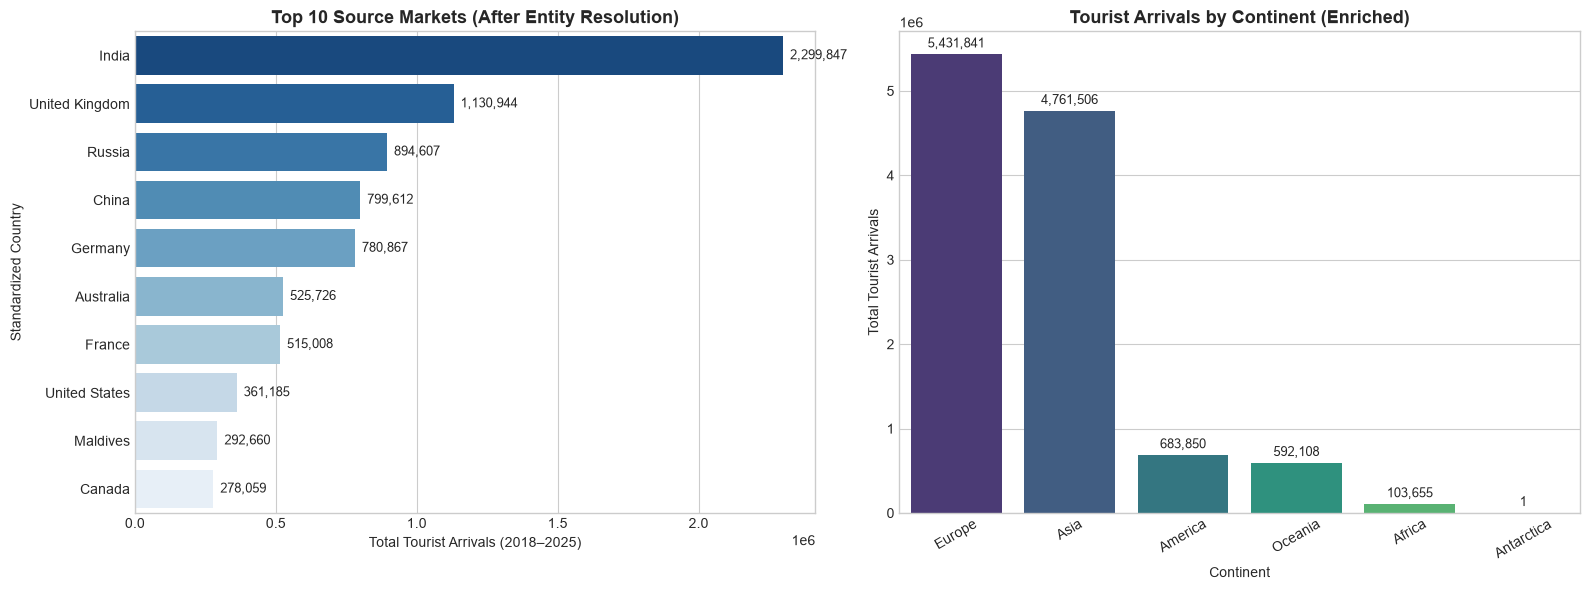

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Top 10 Cleaned Source Markets
top10 = (
    df_cleaned.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=top10,
    x="Tourist_Arrivals",
    y="Country",
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Top 10 Source Markets (After Entity Resolution)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Tourist Arrivals (2018–2025)")
axes[0].set_ylabel("Standardized Country")
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f"{width:,.0f}", (width, p.get_y() + p.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points", va="center", fontsize=9)

# Right: Arrivals by Continent
continent_df = (
    df_cleaned.groupby("Continent")["Tourist_Arrivals"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=continent_df,
    x="Continent",
    y="Tourist_Arrivals",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Tourist Arrivals by Continent (Enriched)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Total Tourist Arrivals")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f"{height:,.0f}", (p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 12. Export Cleaned & Enriched Dataset

In [13]:
df_cleaned.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset successfully exported to: {OUTPUT_PATH}")
print(f"Exported Dimensions: {df_cleaned.shape}")

Cleaned dataset successfully exported to: ..\data\processed\tourism_arrivals_clean.csv
Exported Dimensions: (18288, 11)
